In [13]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# 1. Configuration & Parameters (The "Smarter" Approach)
# -----------------------------------------------------------------------------
# Define base paths relative to the current working directory
DATA_DIR = r"C:\Users\artem\repositories\RRcourse2026\Data"

# Define the target countries and tasks as lists so we can easily add more later
COUNTRIES = ["Belgium", "Spain", "Poland"]
TASKS_NRCA = ["t_4A2a4", "t_4A2b2", "t_4A4a1"]

In [14]:
# -----------------------------------------------------------------------------
# 2. Helper Functions
# -----------------------------------------------------------------------------
def standardize_weighted(df, col_to_std, weight_col, out_col):
    """Calculates the weighted mean and standard deviation, then standardizes."""
    weights = df[weight_col]
    vals = df[col_to_std]
   
    mean_val = np.average(vals, weights=weights)
    variance = np.average((vals - mean_val)**2, weights=weights)
    sd_val = np.sqrt(variance)
   
    df[out_col] = (vals - mean_val) / sd_val
    return df


In [15]:
# -----------------------------------------------------------------------------
# 3. Data Loading & Preprocessing
# -----------------------------------------------------------------------------
# Read O*NET task data and map to 1-digit ISCO08
task_data = pd.read_csv(os.path.join(DATA_DIR, "onet_tasks.csv"))
task_data["isco08_1dig"] = task_data["isco08"].astype(str).str[:1].astype(int)

# Group by 1-digit ISCO and calculate mean task values
aggdata = task_data.groupby("isco08_1dig").mean().drop(columns=["isco08"])

# Read Eurostat employment data iteratively
eurostat_path = os.path.join(DATA_DIR, "Eurostat_employment_isco.xlsx")
isco_dfs = []
for i in range(1, 10):
    df = pd.read_excel(eurostat_path, sheet_name=f"ISCO{i}")
    df['ISCO'] = i
    isco_dfs.append(df)

# Combine all ISCO data into one DataFrame
all_data = pd.concat(isco_dfs, ignore_index=True)

# Calculate totals and shares dynamically using groupby and transform
for country in COUNTRIES:
    # Sum across all ISCOs for each specific TIME period
    all_data[f'total_{country}'] = all_data.groupby('TIME')[country].transform('sum')
    all_data[f'share_{country}'] = all_data[country] / all_data[f'total_{country}']

# Merge employment data with task data
combined = pd.merge(all_data, aggdata, left_on='ISCO', right_on='isco08_1dig', how='left')


In [16]:
# -----------------------------------------------------------------------------
# 4. Task Intensity Calculations
# -----------------------------------------------------------------------------
for country in COUNTRIES:
    # Step A: Standardize individual task items
    for task in TASKS_NRCA:
        combined = standardize_weighted(
            combined,
            col_to_std=task,
            weight_col=f'share_{country}',
            out_col=f'std_{country}_{task}'
        )
   
    # Step B: Calculate the combined task content intensity (NRCA)
    nrca_cols = [f'std_{country}_{task}' for task in TASKS_NRCA]
    combined[f'{country}_NRCA'] = combined[nrca_cols].sum(axis=1)
   
    # Step C: Standardize the combined NRCA metric
    combined = standardize_weighted(
        combined,
        col_to_std=f'{country}_NRCA',
        weight_col=f'share_{country}',
        out_col=f'std_{country}_NRCA'
    )
   
    # Step D: Multiply by share of workers
    combined[f'multip_{country}_NRCA'] = combined[f'std_{country}_NRCA'] * combined[f'share_{country}']


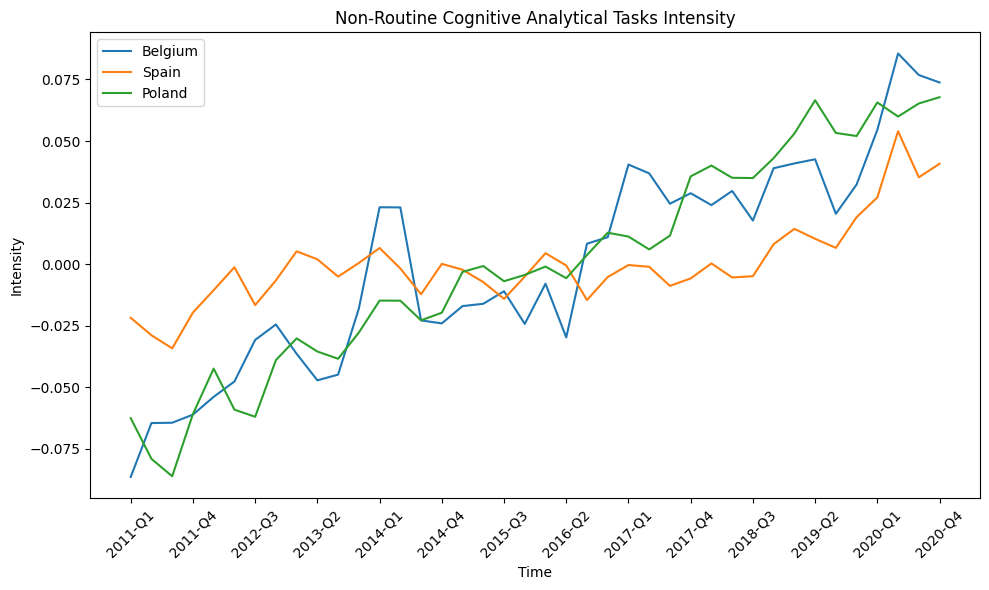

In [17]:
# -----------------------------------------------------------------------------
# 5. Aggregation and Plotting
# -----------------------------------------------------------------------------
plt.figure(figsize=(10, 6))

for country in COUNTRIES:
    # Sum the weighted standardized intensities per TIME period
    agg_df = combined.groupby("TIME")[f"multip_{country}_NRCA"].sum().reset_index()
    plt.plot(agg_df["TIME"], agg_df[f"multip_{country}_NRCA"], label=country)

# Clean up the plot visuals
time_ticks = agg_df["TIME"] # Assuming TIME is identical across aggregated views
plt.xticks(range(0, len(time_ticks), 3), time_ticks[::3], rotation=45)
plt.title("Non-Routine Cognitive Analytical Tasks Intensity")
plt.xlabel("Time")
plt.ylabel("Intensity")
plt.legend()
plt.tight_layout()
plt.show()